# Direct detection with trans-stilbene 

Calculating electron recoil scattering rate in trans-stilbene, using the LCAO wavefunctions for the ground and excited states derived in arXiv:2103.08601. The $\langle f_s^2 | n \ell m \rangle$ coefficients used in this notebook are taken from 2021 data, of $f_s^2(\vec q)$ tabulated on a spherical grid of $\vec q$ points. Enough data was available to reconstruct the $s_1$, $s_2$, $s_5$ and $s_8$ transition form factors using a discrete spherical harmonic transformation. 

## Tabulated Form Factors

Excited states $s_3$ and $s_4$ are not included here, even though they contribute non-negligibly to the rate. The $s_{2,5,8}$ transitions $f_s^2(\vec q)$ were evaluated at polar angles $\theta = 30^\circ, 45^\circ, 60^\circ, 75^\circ, 90^\circ$ on a five-degree grid of $\phi = 0, 5^\circ, 10^\circ, \ldots, 175^\circ$. The form factors vanish at $\theta = 0$, and they are symmetric under $180^\circ$ rotations about the $z$ axis, and under central inversion symmetry $\vec q \rightarrow - \vec q$. The $\langle f_s^2 | n \ell m \rangle$ coefficients were calculated by interpolating $f_s^2(\vec q)$ in $\theta$ to generate better coverage in the polar angle, then performing a discrete spherical harmonic transformation at each fixed value of $|\vec q|$, to extract a 1d function of $q = |\vec q|$ for each $(\ell m)$ mode, $\langle f_s^2 | \ell m \rangle$. The $s_{3,4}$ transitions are not included simply because they were only tabulated with detail at $\theta = 90^\circ$. As a result, the $s_{2,5,8}$ transitions here should be thought of as a placeholder for the systematic error in neglecting the higher excited states. 

From arXiv:2103.08601, the $s_1$ transition always provides the dominant component of the scattering rate, at least for DM masses $m_\chi \leq 100$ MeV. The 2021 data tabulated $f_s^2(\vec q)$ on a five-degree angular grid in $\theta = 5^\circ, 10^\circ, \ldots, 90^\circ$ and in $\phi$. 

The 2021 data was produced over approximately two weeks of non-consecutive cluster time. In the future, we expect it to be much faster to generate $f_s^2(\vec q)$ from standard physical chemistry codes, using gaussian-type orbital basis functions (GTO). The analysis pipeline would calculate $f_s(\vec q)$ from the ground state and final state electronic wavefunctions in the GTO basis, using some analytic results to simplify the integrals, to tabulate $f_s(\vec q)$ on a spherical grid of points. Then, the coefficients $\langle f_s^2 | n \ell m \rangle$ can be found very quickly by performing discrete transforms on the squared $f_s(\vec q)$ data. 

## Crystal Form Factors 

The unit cell of the crystal contains four molecules of trans-stilbene, rotated relative to the crystal $z$ axis (defined in 2103.08601):
$$f_{crys}^2(\vec q) = \sum_{i = 1..4} \mathcal R_i \cdot f_s^2(\vec q),$$
for four rotation operators $\mathcal R_i$ acting on the molecular form factors. 
Aria has applied these rotations to the molecular $\langle f_s^2 | n \ell m \rangle$ coefficients, adding the results together into a single set of $\langle f_{crys}^2 | n \ell m \rangle$, the momentum form factor for one unit cell of the crystal. The total scattering rate, for a detector of mass $M_T$, is proportional to the number of unit cells: 
$$N_{\rm cell} = N_A \frac{M_T}{4 \cdot m_{mol}} = N_A \frac{M_T}{721.0\ \rm g}, $$
where $N_A = 6.022 \cdot 10^{23}$ is Avogadro's number. 


In [1]:
import math
import numpy as np
import numba
import scipy.special as spf
import scipy.interpolate as interp
import vegas # numeric integration
import gvar # gaussian variables; for vegas
import time
import quaternionic # For rotations
import spherical #For Wigner D matrix
# import csv # file IO for projectFnlm
# import os.path
import h5py # database format for mathcalI arrays
import importlib
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as clr
plt.rc('text', usetex=True)

# sys.path.insert(0,'../') #load the local version of vsdm

import vsdm
from vsdm.units import *
from vsdm.utilities import *
from vsdm import McalK

diffM, diffV = vsdm.testG_lm(5, -3, printout=False)
if np.abs(diffV) < 1e-14:
    print("testing 'spherical' and WignerG: PASS")
else:
    print("testing 'spherical' and WignerG: FAIL")
    print("check the version number for 'spherical', and run testD_lm()")
print("vsdm", vsdm.__version__)

testing 'spherical' and WignerG: PASS
vsdm 0.3.8


In [30]:
### Quaternion rotation
# finding the rotation that moves a 'z hat' unit vector to point towards (theta, phi)

def getQ(theta, phi):
    axisphi = phi + np.pi/2 #stationary under R
    axR = theta/2 
    qr = np.cos(axR)
    qi = np.sin(axR) * np.cos(axisphi)
    qj = np.sin(axR) * np.sin(axisphi)
    qk = 0. 
    return quaternionic.array(qr, qi, qj, qk)

def conicalABN(v, a, b, th):
    eq1 = v@v - 1
    eq2 = (v@a - np.cos(th))**2
    eq3 = (v@b - np.cos(th))**2 
    return eq1 + eq2 + eq3

def findCone(thph1, thph2, thetaN):
    assert 0 < thetaN < np.pi/2, "thetaN is defined as interior cone angle, from axis of symmetry"
    theta1, phi1 = thph1 
    theta2, phi2 = thph2 
    ax1 = np.sin(theta1)*np.cos(phi1)
    ay1 = np.sin(theta1)*np.sin(phi1)
    az1 = np.cos(theta1) 
    a1 = np.array([ax1, ay1, az1])
    ax2 = np.sin(theta2)*np.cos(phi2)
    ay2 = np.sin(theta2)*np.sin(phi2)
    az2 = np.cos(theta2) 
    a2 = np.array([ax2, ay2, az2])
    assert a1 @ a2 >= np.cos(2*thetaN), "these two (theta,phi) cannot be fit to the cone."
    
    return a1 @ a2

#

# Specify the position of the north pole in (theta, phi)
# Draw the conical path of the DM wind in the theta, phi plane given the cone opening angle, 2*thetaN
def makeCone(north, thetaN, plotpoints=100):
    thN, phN = north 
    axN = np.sin(thN)*np.cos(phN)
    ayN = np.sin(thN)*np.sin(phN)
    azN = np.cos(thN) 
    axisN = np.array([axN, ayN, azN])
    # defining t=0 as the point of closest approach to the N pole 
    if thN >= thetaN: 
        # cone does not enclose N pole 
        th0 = thN - thetaN
        ph0 = phN
    else:
        th0 = thetaN - thN
        if phN > np.pi:
            ph0 = phN - np.pi
        else:
            ph0 = phN + np.pi
    ax0 = np.sin(th0)*np.cos(ph0)
    ay0 = np.sin(th0)*np.sin(ph0)
    az0 = np.cos(th0) 
    v0 = quaternionic.array([0, ax0, ay0, az0])
    
    # list of rotations to apply to v0:
    rtlist = [2*np.pi * (ix/plotpoints) for ix in range(1, plotpoints+1)]

    conespots = [(th0, ph0)]
    for rt in rtlist:
        qr = quaternionic.array([np.cos(-rt/2)] + [np.sin(-rt/2) * ai for ai in axisN])
        v = qr * v0 / qr
        vr,vth,vph = vsdm.cart_to_sph(v.imag) # new 3-vector -> spherical coords
        # if vth==0 or vth==np.pi:
        #     # phi is undetermined. Set it to match phN
        #     vph = phN
        conespots += [(vth, vph)]
    return np.array(conespots)
        
    
def dailyMod(north, thetaN, plotpoints=100, t0_h=0.):
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    t_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    t = t0_h #initial time, in sidereal hours
    for theta,phi in theta_phi_list:        
        q = 1/getQ(theta, phi) 
        R_list += [q]
        t_list += [t]
        t += dt_h
    return np.array(t_list),R_list

def ix_thetaphi(theta, phi):
    return thetaphilist.index((theta, phi))


#

In [3]:
"""Read in gX and fs2 from CSV files."""

### TRANS-STILBENE FORM FACTORS: s1, s2, s5, s8
# note: excited states s3 and s4 are also important for the rate

QMAX = 24*keV # Global value for q0=qMax for wavelets
Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

VMAX = 820.*km_s # Global value for v0=vMax for wavelets
Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)

DeltaE = {}
DeltaE['s1'] = 4.24*eV
DeltaE['s2'] = 4.788*eV
DeltaE['s5'] = 5.791*eV
DeltaE['s8'] = 6.439*eV

fs2_csv = {}
fs2_csv['s1'] = 'data/fs2crys_s1_nlm.csv'
fs2_csv['s2'] = 'data/fs2crys_s2_nlm.csv'
fs2_csv['s5'] = 'data/fs2crys_s5_nlm.csv'
fs2_csv['s8'] = 'data/fs2crys_s8_nlm.csv'

fs2 = {}
for label in fs2_csv.keys():
    # # Read Fnlm from saved csv file...
    fs2[label] = vsdm.Fnlm(Qbasis, f_type='fs2', use_gvar=False)
    fs2[label].center_Z2 = True
    fs2[label].importFnlm_csv(fs2_csv[label])
    print('{}: ellMax = {}     nCoeffs_q = {}     nMax = {}'.format(label, 
        fs2[label].ellMax, len(fs2[label].f_nlm.keys()), fs2[label].nMax))


### VELOCITY DISTRIBUTION EXAMPLE: SHM 

"""Read from HDF5"""
gX_csv = 'SHM_v250'
gX = vsdm.Fnlm(Vbasis, f_type='gX', use_gvar=False)
gX.importFnlm_csv('data/'+gX_csv+'.csv')
print('gX: ellMax = {}     nCoeffs_v =  {}     nMax = {}'.format(gX.ellMax, 
    len(gX.f_nlm.keys()), gX.nMax))

fs2['gX'] = gX # for convenience, in convergence testing

s1: ellMax = 36     nCoeffs_q = 369664     nMax = 1023
s2: ellMax = 24     nCoeffs_q = 173056     nMax = 1023
s5: ellMax = 24     nCoeffs_q = 173056     nMax = 1023
s8: ellMax = 24     nCoeffs_q = 173056     nMax = 1023
gX: ellMax = 32     nCoeffs_v =  33928     nMax = 7007


In [6]:
### TRANS-STILBENE FORM FACTORS: s1, s2, s5, s8

# QMAX = 24*keV # Global value for q0=qMax for wavelets
# Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

# VMAX = 820.*km_s # Global value for v0=vMax for wavelets
# Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)

# DeltaE = {}
# DeltaE['s1'] = 4.24*eV
# DeltaE['s2'] = 4.788*eV
# DeltaE['s5'] = 5.791*eV
# DeltaE['s8'] = 6.439*eV

"""When creating tstilbene_mK.hdf5, this format was used for the model labels:"""

ellMax = 24
nvMax = 511
nqMax = 1023
lmod = 2

def h5modelname(sI, dmModel, mX_MeV_float=0):
    """Define a consistent style for labeling McalI[dmModel] in this hdf5.

    returns: ('sI') + '/' + ('fdm') + '/' + ('mX_MeV')
        fdm = dmModel['fdm']
        mX_MeV = dmModel['mX']/MeV
    mX_MeV_float controls how many decimal points to include in the
        string version of mX/MeV
    """
    fdm = dmModel['fdm']
    mX_MeV = dmModel['mX'] / MeV
    if mX_MeV_float==0:
        mX_str = str(int(mX_MeV))
    elif mX_MeV_float==1:
        mX_str = '{:.1f}'.format(mX_MeV)
    elif mX_MeV_float==2:
        mX_str = '{:.12}'.format(mX_MeV)
    elif mX_MeV_float==3:
        mX_str = '{:.3f}'.format(mX_MeV)
    mIstr = '{}/{}/{}'.format(sI, fdm, mX_str)
    return mIstr


## Convergence

This section investigates the saved $\langle f_s^2 | n \ell m \rangle$ and $\langle g_\chi | n \ell m \rangle$ coefficients, to see how many actually need to be included in the calculation. If $n_{max}$ and $\ell_{max}$ can be made smaller, the intermediate calculation of the $\mathcal I^{(\ell)}$ matrices will be much faster. 

The conclusion of this section is that very good precision can be achieved with:
- $\ell_{max} = 24$
- $n^{(v)}_{max} = 255$
- $n^{(q)}_{max} = 1023$.
In a sparse method, where only the $N_{\rm coeff}$ largest $\langle f | n \ell m \rangle$ coefficients are kept, similar precision can be attained with $N_{\rm coeff} = 5000$ for $g_\chi$, and $N_{\rm coeff} = 10^5$ for $f_s^2(\vec q)$.

"Very good precision" here means an error of $\Delta \mathcal E < 10^{-6} \mathcal E$, with $\mathcal E$ the $L^2$ norm of the function. 

In [4]:
# Sorted
sume = {}
conv = {}
norm_fs2 = {}

for sI in fs2.keys():
    norm_fs2[sI] = fs2[sI].f2nlm_norm()
    print('energy ({})'.format(sI), norm_fs2[sI])

    sume[sI] = 0.
    conv[sI] = []
# print('{}  \t{}  \t{}'.format('n,l,m', '\tf**2', '\tsum(f**2)'))
    for key,value in fs2[sI].getNLMpower().items():
        power = value/norm_fs2[sI]
        sume[sI] += power
        conv[sI] += [sume[sI]]
        # if power > 1e-2:
        #     print('{}  \t{}  \t{}'.format(key, power, sume))

# norm_fs2['gX'] = gX.f2nlm_norm()
# # print('energy ({})'.format(sI), norm_fs2[sI])
# sume['gX'] = 0.
# conv['gX'] = []
# for key,value in gX.getNLMpower().items():
#     power = value/norm_fs2['gX']
#     sume['gX'] += power
#     conv['gX'] += [sume['gX']]


energy (s1) 0.017621434458072467
energy (s2) 0.0006775418526576988
energy (s5) 0.0012216777968063653
energy (s8) 0.006331997040482243
energy (gX) 2.6767586397804863


In [6]:
powerL = {}
sum_l = {}
conv_l = {}
p_l = {}

for sI in fs2.keys():
    powerL[sI] = fs2[sI].getLpower()
    sum_l[sI] = 0.
    conv_l[sI] = []
    p_l[sI] = []
    print('{}:'.format(sI))
    for key,power in powerL[sI].items():
        power /= norm_fs2[sI]
        sum_l[sI] += power
        p_l[sI] += [[key, power]]
        conv_l[sI] += [sum_l[sI]]
        print('\t{}  \t{:.6G}  \t{}'.format(key, power, sum_l[sI]))
    
    p_l[sI] = np.array(p_l[sI])
    

s1:
	0  	0.584973  	0.5849733857888485
	6  	0.138264  	0.7232372128729314
	4  	0.0908666  	0.8141038098259591
	2  	0.0603996  	0.8745034035222401
	8  	0.0366958  	0.9111992321664982
	10  	0.0278938  	0.9390929860020248
	12  	0.0217787  	0.9608716608169485
	14  	0.0163996  	0.977271300831541
	16  	0.00782497  	0.9850962744332483
	18  	0.00498058  	0.9900768511732556
	20  	0.00339199  	0.9934688456083116
	22  	0.00219485  	0.9956636914503993
	24  	0.00162989  	0.997293584842515
	26  	0.00075586  	0.998049444408636
	28  	0.00070402  	0.9987534645143463
	30  	0.000564853  	0.9993183170548171
	34  	0.000305173  	0.9996234896043112
	32  	0.000230826  	0.9998543156035413
	36  	0.000145684  	1.000000000000068
s2:
	0  	0.608864  	0.6088637155459333
	2  	0.232602  	0.8414659485589081
	10  	0.043153  	0.8846189437892903
	8  	0.0321525  	0.9167714601017422
	6  	0.0203761  	0.9371475136903104
	12  	0.0202372  	0.9573847337083102
	4  	0.0181069  	0.9754916645572816
	14  	0.014447  	0.989938643575609

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_49864/3031462360.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


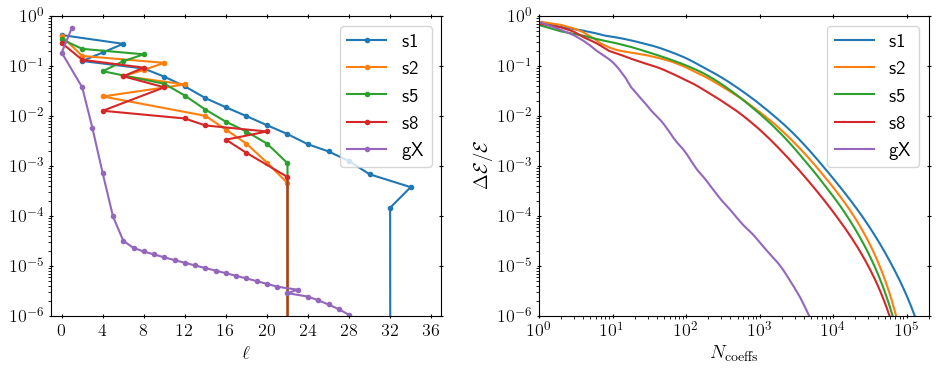

In [7]:
unisize = 3
fig = plt.figure(figsize=[1.3*unisize,unisize])
labels = 13
largelabels = 14
ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='log')

for sI in powerL.keys():
    ax.plot([l for l in powerL[sI].keys()], 1-np.array(conv_l[sI]), 
            marker='.', label=sI)

# ax.plot(p_l[:,0],p_l[:,1], color='gray',
#         marker='.', linestyle='None', label=r'$\mathcal{P}_\ell / \mathcal{E}$')

# ax.plot([l for l in powerL_alt.keys()], 1-np.array(conv_l_alt), 
#         marker='.', color='purple', label=r'$\Delta\mathcal{E} / \mathcal{E}$ [alt]')
# ax.plot(p_l_alt[:,0],p_l_alt[:,1], 
#         marker='.', linestyle='None', label=r'$\mathcal{P}_\ell / \mathcal{E}$ [alt]')

ax.set_xlim([-1, 37])
ax.set_xticks([4*j for j in range(10)])
ax.set_ylim([1e-6, 1])
ax.set_xlabel(r'$\ell$', fontsize=largelabels, usetex=True)
# ax.set_ylabel(r'$\Delta\mathcal{E} / \mathcal{E}$', fontsize=largelabels, usetex=True)
ax.tick_params(axis='both', labelsize=labels, direction='inout',
               right=True, top=True, labelleft=True, labelright=False,
               labelbottom=True, labeltop=False)
ax.legend(loc='upper right', fontsize=largelabels)

ax2 = fig.add_axes([1.25,0,1,1], xscale='log', yscale='log')
for sI in conv.keys():
    ax2.plot([i+1 for i in range(len(conv[sI]))], 1-np.array(conv[sI]), 
             label=sI)
# ax2.plot([i+1 for i in range(len(conv_alt))], 1-np.array(conv_alt), 
#          color='purple', 
#          label=r'$n = (3, 2, 1)$')
ax2.set_xlim([1, 2e5])
ax2.set_ylim([1e-6, 1])
ax2.set_xlabel(r'$N_{\rm coeffs}$', fontsize=largelabels, usetex=True)
ax2.set_ylabel(r'$\Delta\mathcal{E} / \mathcal{E}$', fontsize=largelabels, usetex=True)
ax2.tick_params(axis='both', labelsize=labels, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax2.legend(loc='upper right', fontsize=largelabels)

fig.show()

In [19]:
powerLM = {}
sortlm = {}
sum_lm = {}
conv_lm = {}
p_nlm = {}
p_lm_n = {}
sump_lm_n = {}


for sI in fs2.keys():
    powerLM[sI] = fs2[sI].getLMpower()
    sortlm[sI] = sorted(powerLM[sI].items(), key=lambda z: z[1], reverse=True)

    sum_lm[sI] = 0.
    conv_lm[sI] = []
    i = 0
    print('{}:'.format(sI))
    for entry in sortlm[sI]:
        key, power = entry
        powerLM[sI][key] = power
        power /= norm_fs2[sI]
        sum_lm[sI] += power
        conv_lm[sI] += [sum_lm[sI]]
        if i < 6:
            print('\t{}  \t{:.6G}  \t{}'.format(key, power, sum_lm[sI]))
        i += 1
    
    p_nlm[sI] = fs2[sI].getNLMpower(lMax=24)
    p_lm_n[sI] = {}
    sump_lm_n[sI] = {}
    n_coeffs_n = 2**10
    for lmP in sortlm[sI][0:9]:
        (lm,P) = lmP
        plm = P
        p_lm_n[sI][lm] = [p_nlm[sI][(n, lm[0], lm[1])]/plm for n in range(n_coeffs_n)]
        sump = 0.0
        sump_lm_n[sI][lm] = np.zeros(n_coeffs_n)
        for n in range(n_coeffs_n):
            sump += p_lm_n[sI][lm][n]
            sump_lm_n[sI][lm][n] = sump


s1:
	(0, 0)  	0.584973  	0.5849733857888485
	(4, 0)  	0.0546065  	0.639579933996475
	(6, -4)  	0.0486493  	0.6882291935106084
	(2, 0)  	0.0350436  	0.7232727967594986
	(6, 0)  	0.0344588  	0.757731593729529
	(6, 6)  	0.0233045  	0.7810360658047694
s2:
	(0, 0)  	0.608864  	0.6088637155459333
	(2, 0)  	0.220747  	0.8296110992956097
	(4, -4)  	0.0103426  	0.8399537022570658
	(8, -2)  	0.00915479  	0.8491084880277192
	(10, 6)  	0.00811624  	0.8572247230590277
	(10, -2)  	0.00781493  	0.865039656233837
s5:
	(0, 0)  	0.659951  	0.6599507357713543
	(2, 0)  	0.104552  	0.7645025151598026
	(4, -4)  	0.0278208  	0.7923232938125652
	(8, 6)  	0.0164562  	0.8087795212366117
	(6, 6)  	0.012495  	0.8212744859200191
	(10, 6)  	0.0117234  	0.8329978829009542
s8:
	(0, 0)  	0.712291  	0.7122905973817197
	(2, 0)  	0.150606  	0.8628967610579301
	(4, -4)  	0.0146623  	0.8775591029850192
	(6, -2)  	0.0122308  	0.8897898966387591
	(8, -2)  	0.0109441  	0.9007339604875924
	(8, 8)  	0.00928734  	0.9100213005818

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_49864/2051764786.py:93: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


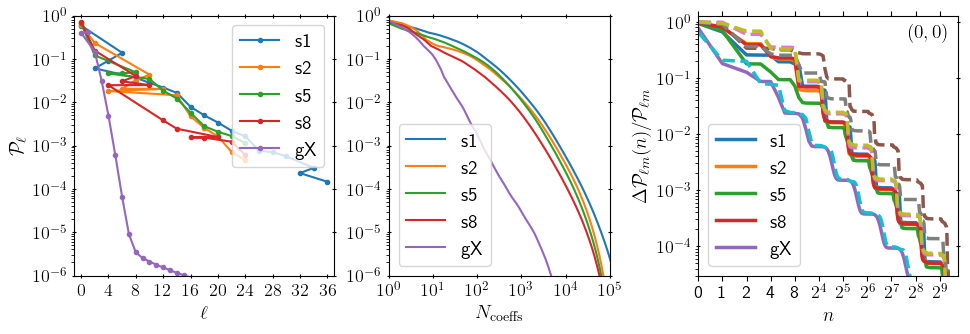

In [22]:
unisize = 2.6
fig = plt.figure(figsize=[1.*unisize,unisize])
labels = 13
fonts = 14

largelabels = 14
nsize = 2**10
ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='log')
# for sI in fs2.keys():
#     ax.plot([l for l in powerL[sI].keys()], 1-np.array(conv_l[sI]), 
#             marker='.',label=sI)
for sI in fs2.keys():
    ax.plot(p_l[sI][:,0],p_l[sI][:,1], 
            marker='.', label=sI)
ax.set_xlim([-1, 37])
ax.set_xticks([4*j for j in range(10)])
ax.set_ylim([1e-7, 1])
ax.set_xlabel(r'$\ell$', fontsize=largelabels, usetex=True)
ax.set_ylabel(r'$\mathcal P_\ell$', fontsize=largelabels, usetex=True)
ax.tick_params(axis='both', labelsize=labels, direction='inout',
               right=True, top=True, labelleft=True, labelright=False,
               labelbottom=True, labeltop=False)
ax.legend(loc='upper right', fontsize=largelabels)
# ax.text(0.96, 0.04, r'$\vec{n}=(1,1,2)$', horizontalalignment='right',
#          verticalalignment='bottom', fontsize=fonts, 
#          color='black', backgroundcolor='white',
#          transform=ax.transAxes, usetex=True)

ax2 = fig.add_axes([1.21,0,0.85,1], xscale='log', yscale='log')
for sI in fs2.keys():
    ax2.plot([i+1 for i in range(len(conv[sI]))], 1-np.array(conv[sI]), 
             label=sI)
ax2.set_xlim([1, 1e5])
ax2.set_ylim([1e-6, 1])
ax2.set_xticks([10**j for j in range(6)])
ax2.set_xlabel(r'$N_{\rm coeffs}$', fontsize=largelabels, usetex=True)
ax2.tick_params(axis='both', labelsize=labels, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax2.legend(loc='lower left', fontsize=largelabels)


lm_B = (2, 0)
lm_A = (0, 0)
# lm_C = (4, 4)

ax3 = fig.add_axes([2.4,0,1,1], xscale='log', yscale='log')
nlist0 = [0.5]+[n for n in range(1,nsize)]
# for lbl in p_lm_n.keys():
#     if lbl != lm_A and lbl != lm_B and lbl != lm_C:
#         ax3.plot(nlist0, 1-sump_lm_n[lbl], color='gray')
for sI in fs2.keys():
    ax3.plot(nlist0, 1-sump_lm_n[sI][lm_A], linewidth=2.5,
             label=sI)
for sI in fs2.keys():
    ax3.plot(nlist0, 1-sump_lm_n[sI][lm_B], linewidth=2.5,
             linestyle='dashed')
# ax3.plot(nlist0, 1-sump_lm_n[lm_B], linewidth=2.5,
#          color='mediumblue', label=r'${}$'.format(lm_B))
# ax3.plot([n for n in range(nsize)], 1-sump_lm_n[lm_C], 
#          color='red', label=r'${}$'.format(lm_C), 
#          linewidth=2.5)
# ax3.plot([n for n in range(nsize)], 1-sump_lm_n[(4,4)], 
#          color='darkorange', label=r'$(4,4)$')

# ax3.set_xlim([0, 96])
power2_plot = 10
ax3.set_xlim([1, 0.85*2**power2_plot])
ax3.set_ylim([3e-5, 1.3])
ax3.set_xticks([2**j for j in range(-1,power2_plot)], 
               labels=(["0"]+[str(int(2**j)) for j in range(4)] 
                       + [r"$2^{}$".format(j) for j in range(4, power2_plot)])
              )
ax3.set_xlabel(r'$n$', fontsize=largelabels, usetex=True)
ax3.set_ylabel(r'$\Delta \mathcal{P}_{\ell m}(n) / \mathcal{P}_{\ell m}$', 
               fontsize=largelabels, usetex=True)
ax3.tick_params(axis='x', labelsize=labels, direction='out',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax3.tick_params(axis='x', which='minor', bottom=False)
ax3.tick_params(axis='y', labelsize=labels, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax3.legend(loc='lower left', fontsize=largelabels)
ax3.text(0.97, 0.97, r'${}$'.format(lm_A), horizontalalignment='right',
         verticalalignment='top', fontsize=fonts, 
         color='black', backgroundcolor='white',
         transform=ax3.transAxes, usetex=True)

# plt.savefig('out/fs2_convergence.pdf', format="pdf", bbox_inches='tight')


fig.show()

### Conclusions (re: convergence): 

$\mathcal P_\ell$ for the momentum form factors decreases relatively slowly at higher $\ell$, but by $\ell > 24$, $\mathcal P_\ell < 10^{-3} \mathcal E$ in each case. The velocity distribution converges much more quickly, dropping below $\mathcal P_\ell < 10^{-5}$ by $\ell = 8$. The higher-$\ell$ tail decreases as a slower power law, probably as a result of the sharp cutoff at the escape velocity in the standard halo model. 

As a function of radial index $n$, the individual spherical harmonic modes are generally well fit by $n_{\rm max} \lesssim 2^{10}$. For the velocity distribution, $n_{\rm max} = 2^8$ is sufficient. 

This information can be used to restrict the size of the McalI matrix $\mathcal I^{(\ell)}_{nv, nq}$: for example, taking $\ell_{\rm max} = 24$, $n^{(v)}_{\rm max} = 255$, and $n^{(q)}_{\rm max} = 1023$ should reproduce the rate with negligible truncation error.

# Evaluation of $\mathcal I$ and $K$ matrices

This is a moderately time consuming stage of the calculation. It only needs to be done once per combination of DM model $(m_\chi, n)$ and excitation energy $\Delta E$. In this notebook there are four values of $\Delta E$, for the $s_1$, $s_2$, $s_5$, and $s_8$ transitions, and two values of $n$: $n=0$ for $F_{DM} = 1$, and $n=2$ for $F_{DM} = 1/q^2$. In the precise calculation, it takes 15-20 minutes to evaluate each $\mathcal I$. 

If the user anticipates repeating this calculation for additional velocity distributions $g_\chi(\vec v)$ in the future, and storage space is not limited, then it may make sense to save these $\mathcal I^{(\ell)}$ into an hdf5 file, using the built-in McalI.writeMcalI() method. These files can be ~100 MB per model. 

Once all of the partial rate matrices $K$ have been evaluated, for every combination of $g_\chi$ and $f_s^2$, there is no further need for $\mathcal I$. In this scenario it makes more sense to save the values of $K^{(\ell)}$ instead. This object can be orders of magnitude smaller than the $\mathcal I$ array: in this notebook, the $K$ file is smaller by a factor about 400. 

This **Evaluation** section of the notebook must be run any time new values of $m_\chi$ are added to the list. Alternatively, $\mathcal I$ can be calculated using the Julia version of the code (20-50 times faster), available at https://ariaradick.github.io/VectorSpaceDarkMatter.jl/. 


## Kinematic Scattering Matrix 

Calculating the $\mathcal I^{(\ell)}$ matrices for a given DM model (or list of models).

Due to the size of the 3d array $\mathcal I^{(\ell)}_{n n'}$, the saved values for each DM model and transition energy $\Delta E$ are not included with the notebook. It can take about 20 minutes to calculate each array: in this example, with fixed $m_\chi = 10$ MeV and both form factors $n = 0,2$, there are a total of eight $\mathcal I$ arrays, including four of the excited states $s_{1,2,5,8}$. 

Once these have been evaluated, the McalI class includes a method McalI.writeMcalI() that saves all of the $\mathcal I$ values to a single hdf5 file. The file may be as large as a few GB. 

Note to the user: If the long McalI evaluation time is limiting your analysis, the Julia version of this code (https://ariaradick.github.io/VectorSpaceDarkMatter.jl/) can be 20 to 50 times faster. 

In [23]:
flabel = 's1'

gX_eg = gX
fs2_eg = fs2[flabel]

ellMax = np.min([gX_eg.ellMax, fs2_eg.ellMax])
nvMax = gX_eg.nMax
nqMax = fs2_eg.nMax
print(ellMax, nvMax, nqMax)

32 7007 1023


In [25]:
"""Comprehensive mI calculation for larger list of DM masses:

Following the results from 'Convergence', use a smaller ellMax and nMax:
"""
ellMax = 24
nvMax = 255
nqMax = 1023


# ls10 = [1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9]
# p10 = [1, 10, 100]
ls10 = [1]
p10 = [10]
mXlist = np.array([p*m for p in p10 for m in ls10])
# mXlist = mXlist[0:25]

"""Check the evaluation time for mcalI:"""
mI = {}
modelsDM = []
t0 = time.time()
for sI in ['s1', 's2', 's5', 's8']:
    for fn in [0,2]:
        for mX in mXlist:
            modelsDM += [(mX, fn)]
            dmModel = dict(mX=mX*MeV, fdm_n=fn, mSM=mElec, DeltaE=DeltaE[sI])
            mI[(sI, mX, fn)] = vsdm.McalI(Vbasis, Qbasis, dmModel, 
                                          mI_shape=(ellMax+1, nvMax+1,nqMax+1), 
                                          center_Z2=True, 
                                          use_gvar=False, do_mcalI=True)
            print((sI, mX, fn), ": ", mI[(sI, mX, fn)].t_eval)
tEvalI = time.time() - t0

('s1', 10, 0) :  1168.5289540290833
('s1', 10, 2) :  1179.9567849636078
('s2', 10, 0) :  1125.5535571575165
('s2', 10, 2) :  1125.777191877365
('s5', 10, 0) :  1044.4740281105042
('s5', 10, 2) :  1127.2051331996918
('s8', 10, 0) :  1077.0396041870117
('s8', 10, 2) :  1008.3678748607635


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_49864/2026743686.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.matshow(np.log10(mI[('s1', 10, 0)].mcalI[0][0:128, 0:128]), cmap='viridis')
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_49864/2026743686.py:1: RuntimeWarning: invalid value encountered in log10
  plt.matshow(np.log10(mI[('s1', 10, 0)].mcalI[0][0:128, 0:128]), cmap='viridis')


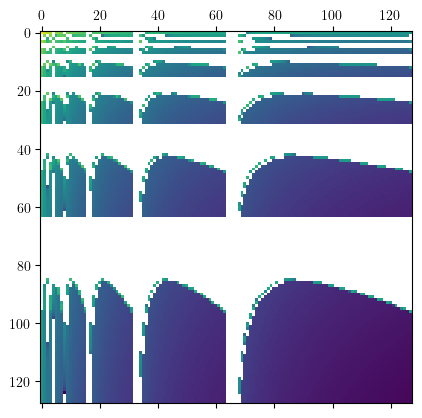

In [31]:
plt.matshow(np.log10(mI[('s1', 10, 0)].mcalI[0][0:128, 0:128]), cmap='viridis')

In [36]:
"""Save the results to hdf5:""" 
hdf5file = 'out/rates_sI.hdf5'
for sImXfn in mI.keys():
    mI[sImXfn].writeMcalI(hdf5file, str(sImXfn))

## Calculate Partial rate matrix $K^{(\ell)}$ from $\mathcal I^{(\ell)}$:

Compared to $\mathcal I$, this part of the calculation is very fast. Only if the number of distinct $g_\chi$ models is very large (e.g. more than one hundred) will this step take a relevant amount of time. 

In [33]:

t0 = time.time()
rates = {}
mK = {}
print('\t tEval[K]:')
for sI_m_n in mI.keys():
    (sI, mX, n) = sI_m_n
    rates[sI_m_n] = vsdm.RateCalc(gX, fs2[sI], mI[sI_m_n], use_gvar=False, sparse=False)
    print(sI_m_n, ": ", rates[sI_m_n].t_eval)
tEvalR = time.time() - t0
# print(tEvalR)

	 tEval[K]:
('s1', 10, 0) :  3.9399333000183105
('s1', 10, 2) :  3.807345151901245
('s2', 10, 0) :  1.252851963043213
('s2', 10, 2) :  1.0549771785736084
('s5', 10, 0) :  1.0563912391662598
('s5', 10, 2) :  1.0028948783874512
('s8', 10, 0) :  1.1020421981811523
('s8', 10, 2) :  1.0447759628295898


### Saving McalK matrix to CSV:

It is very fast to generate $K^{(\ell)}$ from $\mathcal I^{(\ell)}$, once $\mathcal I$ is known. Because $\mathcal I$ is such a large object, however, it is much more convenient to save and share the values of $K^{(\ell)}_{mm'}$ for each combination of DM model, $g_\chi$, and $f_s^2$. The RateCalc and McalK classes save $K$ in a vector format, so a list of $K$ for different DM models and excitation energies can be saved as a single 2d array. 

Even after skipping the odd values of $\ell$, the great majority of $K^{(\ell)}_{m m'}$ coefficients are zero. For the $SHM$, only rows with $m = 0$ can contribute; and with t-stilbene, only even values of $m'$ are nonzero. 

In [246]:
KindexList = []
for sI in ['s1', 's2', 's5', 's8']:
    for mX in mXlist:
        for n in [0,2]:
            sI_m_n = (sI, mX, n)
            KindexList += [sI_m_n] 
# this list is for tracking here the order of the rows of the 2d array K[model][lmk]
len_lmk = len(rates[KindexList[0]].vecK)
N_DM_E_models = len(KindexList)
print('size of K array:', (N_DM_E_models, len_lmk))
Kmodel_array = np.zeros((N_DM_E_models, len_lmk))
for ix,sI_m_n in enumerate(KindexList):
    Kmodel_array[ix,:] = rates[sI_m_n].vecK
# save K array to CSV:
K_csv_name = 'out/Karray_s1258_mX{}.csv'.format(mX)
np.savetxt(K_csv_name, Kmodel_array)

size of K array: (8, 11037)


In [240]:
print(Kmodel_array[0,0:18])

[ 2.21406028  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         -0.03151167
  0.          0.0982284   0.         -0.05302036  0.          0.        ]


## Organizing K matrices from CSV and HDF5:

Combining $m_\chi = 10$ MeV (from CSV) with the other values (from HDF5). Saves the combined mcalK values to a single HDF5 file. 

In [7]:


"""When creating Karray_s1258_mX10.csv, this sequence of models was used:"""
KindexList = []
for sI in ['s1', 's2', 's5', 's8']:
    for mX in [10]:
        for n in [0,2]:
            sI_m_n = (sI, mX, n)
            KindexList += [sI_m_n] 
# # this list is for tracking here the order of the rows of the 2d array K[model][lmk]
# len_lmk = len(rates[KindexList[0]].vecK)
# N_DM_E_models = len(KindexList)
# print('size of K array:', (N_DM_E_models, len_lmk))
# # Kmodel_array = np.zeros((N_DM_E_models, len_lmk))

K_csv_name = 'data/Karray_s1258_mX{}.csv'.format(10)

Kmodel_array = np.loadtxt(K_csv_name)
print('size of K array:', np.shape(Kmodel_array))


size of K array: (8, 11037)


In [12]:
Kmodel_array[1,0:16]

array([ 0.56313444,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.0081548 ,  0.        ,  0.07709715,  0.        ,
       -0.00112153])

In [21]:
hdf5file = 'data/TSB_mK.hdf5'

with h5py.File(hdf5file,'r') as hdf5:
    print(hdf5['s1/0'].keys())

<KeysViewHDF5 ['100', '2', '20', '3', '30', '5', '50']>


In [22]:
hdf5file = 'out/TSB_mK.hdf5'

ix = 0
with h5py.File(hdf5file,'a') as hdf5:
    for sI in ['s1', 's2', 's5', 's8']:
        for mX in [10]:
            for fdm in [0,2]:
                dmModel = dict(mX=mX*MeV, fdm=fdm, mSM=mElec, DeltaE=DeltaE[sI])
                thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
                print(thislabel)
#                 group = hdf5.create_group(thislabel)
                vecK = Kmodel_array[ix,:]
                ix += 1
                dset = hdf5.create_dataset(thislabel+'/mcalK', data=vecK)
    
    

s1/0/10
s1/2/10
s2/0/10
s2/2/10
s5/0/10
s5/2/10
s8/0/10
s8/2/10


In [27]:
hdf5file = 'out/TSB_mK.hdf5'

with h5py.File(hdf5file,'a') as hdf5:
    for sI in ['s1', 's2', 's5', 's8']:
        for mX in [10]:
            for fdm in [0,2]:
                dmModel = dict(mX=mX*MeV, fdm=fdm, mSM=mElec, DeltaE=DeltaE[sI])
                thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
                hdf5[thislabel].attrs.update(dict(gX_vE_kms=250., sI=sI))
                hdf5[thislabel].attrs.update(dmModel)


In [37]:
with h5py.File(hdf5file,'a') as hdf5:
    print(hdf5['s1/0/10'].attrs.keys())
    print(hdf5['s1/0/10'].attrs['gX_vE_kms'])
    

<KeysViewHDF5 ['DeltaE', 'fdm', 'gX_vE_kms', 'mSM', 'mX', 'sI']>
250.0


In [38]:
"""saved the combined HDF5 file as 'tstilbene_mK':"""
with h5py.File('data/tstilbene_mK.hdf5','r') as hdf5:
    print(hdf5['s1/0/10/mcalK'][0:15])

[ 2.21406028  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         -0.03151167
  0.          0.0982284   0.        ]


# Rate Calculation

It is possible to skip the previous parts of the notebook (evaluating $\mathcal I$ and $K$), and to read in $K^{(\ell)}$ directly from the saved CSV file of the form 'data/Karray_s1258.csv'. For this, the user needs to know which DM models correspond to each row of the Karray, as well as the values of ellMax and lmod. 



In [4]:
# """Option 1: import from CSV"""

# mXlist = [10]
# ellMax = 24

# KindexList = []
# for sI in ['s1', 's2', 's5', 's8']:
#     for mX in mXlist:
#         for n in [0,2]:
#             sI_m_n = (sI, mX, n)
#             KindexList += [sI_m_n] 

# K_csv_name = 'data/Karray_s1258_mX10.csv'
# Kmodel_array = np.loadtxt(K_csv_name)

# print(np.shape(Kmodel_array))
# print(Kmodel_array[0,0:18])
# # compare these values to the values in the savetxt() version:

# rates = {}
# for ix,sI_m_n in enumerate(KindexList):
#     newK = McalK(ellMax, lmod=2)
#     newK.vecK = Kmodel_array[ix,:]
#     rates[sI_m_n] = newK

In [7]:
"""Option 2: import from HDF5"""

ellMax = 24
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

rates = {}
with h5py.File('data/tstilbene_mK.hdf5','r') as hdf5:
    for sI in ['s1', 's2', 's5', 's8']:
        for n in [0,2]:
            for mX in mXlist:
                dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
                thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
                dataK = hdf5[thislabel+'/mcalK'][:]
                newK = McalK(ellMax, lmod=2)
                newK.vecK = dataK
                rates[(sI, n, mX)] = newK


In [8]:
rates[('s5', 0, 30)].vecK[0:18]

array([ 0.15413025,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.00045079,  0.        ,  0.015294  ,  0.        ,
       -0.00154869,  0.        ,  0.        ])

### Combinations of mcalK: 

In addition to the individual $s_i$ transitions, and their sum, it is interesting to see how each $s_{i > 1}$ alters the $s_1$-only prediction. The combined rate can be found by adding together the partial rate matrices, $K(s_1) + K(s_i)$.

In [9]:
for mX in mXlist:
    for n in [0, 2]:
        vecK_s1 = rates[('s1', n, mX)].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            lbl = 's1' + sI
            vecK_other = rates[(sI, n, mX)].vecK
            vecK_tot += vecK_other
            newK = McalK(ellMax, lmod=2)
            newK.vecK = vecK_s1 + vecK_other
            rates[(lbl, n, mX)] = newK
        newK = McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates[('tot', n, mX)] = newK

In [10]:
mX = mXlist[0]
n = 0
print('K_000 for mX = {} MeV, n = {}:'.format(mX, n))
for lbl in ['s1', 's2', 's5', 's8','s1s2', 's1s5', 's1s8', 'tot']:
    K000 = rates[(lbl, n, mX)].vecK[0]
    print('{}:\t{}'.format(lbl, K000))

# print('testing sum:')
ix = 3
test12 = rates[('s1', n, mX)].vecK[ix] + rates[('s2', n, mX)].vecK[ix] - rates[('s1s2', n, mX)].vecK[ix] 
print('s1 + s2 - s1s2 = {}'.format(test12))

K_000 for mX = 2 MeV, n = 0:
s1:	0.26110669318521496
s2:	0.02019800604368375
s5:	0.004980659625188013
s8:	0.0007544466679906464
s1s2:	0.2813046992288987
s1s5:	0.26608735281040297
s1s8:	0.2618611398532056
tot:	0.28703980552207736
s1 + s2 - s1s2 = 0.0


## Rotations

This section evaluates the WignerG matrix for a long list of rotations. For 2d plots of $\mathcal R(\theta, \phi)$, the rotations are organized into a 2d array, with $\theta$ and $\phi$ the spherical coordinates of the Earth velocity vector in the reference frame of the crystal. 

To make fine-grained plots, this section uses a grid of about 16000 detector orientations. Evaluating all of the $G^{(\ell)}$ matrices can take a couple minutes, with $\ell_{max} = 24$. The daily modulation rates will be evaluated separately using this same method, even though this grid of $R(\theta, \phi)$ is fine enough for interpolation to be accurate. 

In [12]:
rotationlist = []
rotationarray = []
thetaphilist = []

for theta in range(0, 181, 2):
    rrow = []
    for phi in range(0, 361, 2):
        # for WignerG, want to apply the inverse of getQ.
        # getQ applied to vE moves vE from the z axis to the position (theta, phi). 
        # 1/getQ applied to the crystal does the same thing, 
        #     with vE -> (theta, phi) in the frame of the crystal.
        q = 1/getQ(theta * np.pi/180, phi * np.pi/180) 
        rrow += [q] 
        rotationlist += [q] 
        thetaphilist += [(theta, phi)]
    rotationarray += [rrow]

rotationarray = np.array(rotationarray)
# thetaphilist = np.array(thetaphilist)
np.shape(rotationarray)

(91, 181, 4)

In [13]:
t0 = time.time()
wG = vsdm.WignerG(ellMax, rotations=rotationlist, lmod=2)
tG = time.time() - t0
print(tG)
print(len(rotationlist))
print(tG/len(rotationlist))

116.26593708992004
16471
0.007058826852645258


### Calculate the rate for each rotation

This step takes the dot product between the $K(\ell, m, m')$ vector and all of the $G^{(\ell)}$ vectors, for every combination of DM model and $\Delta E$. 

This version of the rate calculation uses McalK.mu_R_l() rather than McalK.mu_R(), to evaluate each $\ell$ mode $R_\ell$ separately. This data can be used to show that the higher $\ell$ modes are as unimportant as expected. It might take a minute to evaluate all the combinations, though: the mu_R() method is faster, if only the total rate $R = \sum_\ell R_\ell$ is needed.


In [14]:
t0 = time.time()
# mu_all = {}
rate_all = {}
rate_angavg = {}
for key in rates.keys():
#     mu_R_l = rates[key].mu_R_l(wG)
#     rate_R = mu_R_l.sum(axis=1)
#     mu_all[key] = mu_R_l
    rate_R = rates[key].mu_R(wG)
    rate_all[key] = rate_R
    rate_angavg[key] = rates[key].vecK[0] # the ell=0 component of vecK is the angular average
    print('{}: <R> = {}'.format(key, rate_angavg[key]))
tR = time.time() - t0
print(tR)
print(tR/len(rate_R)/len(rates.keys()))

('s1', 0, 2): <R> = 0.26110669318521496
('s1', 0, 3): <R> = 1.1943110453302204
('s1', 0, 5): <R> = 2.281252884427315
('s1', 0, 10): <R> = 2.21406027716445
('s1', 0, 20): <R> = 1.4047543370082183
('s1', 0, 30): <R> = 0.9966933323724457
('s1', 0, 50): <R> = 0.6246439727724538
('s1', 0, 100): <R> = 0.32153665330214154
('s1', 2, 2): <R> = 0.15873937910755612
('s1', 2, 3): <R> = 0.47387818108455476
('s1', 2, 5): <R> = 0.6874083395298799
('s1', 2, 10): <R> = 0.563134443744161
('s1', 2, 20): <R> = 0.34178521535459067
('s1', 2, 30): <R> = 0.2412294460711693
('s1', 2, 50): <R> = 0.1510947811480764
('s1', 2, 100): <R> = 0.07790502236730842
('s2', 0, 2): <R> = 0.02019800604368375
('s2', 0, 3): <R> = 0.1009528864094404
('s2', 0, 5): <R> = 0.22176346045969672
('s2', 0, 10): <R> = 0.2391029117414762
('s2', 0, 20): <R> = 0.1581593967275145
('s2', 0, 30): <R> = 0.11355866246883008
('s2', 0, 50): <R> = 0.0718003359508107
('s2', 0, 100): <R> = 0.03719116181609212
('s2', 2, 2): <R> = 0.0189451830273869
(

In [15]:
r_avg_min_max = {}
for key in rate_all.keys():
    rate_R = np.array(rate_all[key])
    rate_avg = rate_angavg[key]
    least = rate_R.min()
    greatest = rate_R.max()
    r_avg_min_max[key] = [rate_avg, least, greatest]
    print('{}: {:.4g}\t{:.4g}\t{:.4g}'.format(key, rate_avg, least/rate_avg, greatest/rate_avg))
    

('s1', 0, 2): 0.2611	0.6923	1.225
('s1', 0, 3): 1.194	0.804	1.151
('s1', 0, 5): 2.281	0.8983	1.089
('s1', 0, 10): 2.214	0.9585	1.05
('s1', 0, 20): 1.405	0.9707	1.039
('s1', 0, 30): 0.9967	0.9728	1.036
('s1', 0, 50): 0.6246	0.9744	1.034
('s1', 0, 100): 0.3215	0.9758	1.032
('s1', 2, 2): 0.1587	0.7737	1.298
('s1', 2, 3): 0.4739	0.8477	1.242
('s1', 2, 5): 0.6874	0.8941	1.189
('s1', 2, 10): 0.5631	0.9249	1.149
('s1', 2, 20): 0.3418	0.9337	1.131
('s1', 2, 30): 0.2412	0.9349	1.125
('s1', 2, 50): 0.1511	0.9355	1.12
('s1', 2, 100): 0.07791	0.9357	1.116
('s2', 0, 2): 0.0202	0.6536	1.686
('s2', 0, 3): 0.101	0.7641	1.246
('s2', 0, 5): 0.2218	0.8668	1.085
('s2', 0, 10): 0.2391	0.9362	1.064
('s2', 0, 20): 0.1582	0.95	1.076
('s2', 0, 30): 0.1136	0.9505	1.081
('s2', 0, 50): 0.0718	0.9499	1.085
('s2', 0, 100): 0.03719	0.9489	1.089
('s2', 2, 2): 0.01895	0.4868	1.936
('s2', 2, 3): 0.06772	0.636	1.656
('s2', 2, 5): 0.1056	0.7178	1.504
('s2', 2, 10): 0.0923	0.7584	1.422
('s2', 2, 20): 0.05822	0.7732	1.388


### Partial rate expansion in $R_\ell$:

In [22]:
# """Partial Rate expansion in ell..."""
# mu_norm = {}
# for key in rate_all.keys():
#     mu_norm[key] = mu_all[key][:, :]/rate_angavg[key]
    


In [20]:
ells = np.array([j for j in range(0, ellMax+1, 2)])
print(ells)

[ 0  2  4  6  8 10 12 14 16 18 20 22 24]


In [23]:
# unisize = 3.5
# fig = plt.figure(figsize=[2.0*unisize,1*unisize])
# ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='log')

# mX = 10
# n = 0
# # sIlist = ['s1', 's2', 's5', 's8']

# for j in range(100):
#     i = np.random.randint(0, len(rotationlist))
#     ax.plot(ells, np.abs(mu_norm[('s1', n, mX)][i]), color='mediumpurple')
#     ax.plot(ells, np.abs(mu_norm[('s2', n, mX)][i]), color='gray')
#     ax.plot(ells, np.abs(mu_norm[('tot', n, mX)][i]), color='cornflowerblue')

# ax.plot(ells, -np.abs(mu_norm[('s1', n, mX)][100]), color='mediumpurple', 
#         label=r'{}, $m_\chi={}$ MeV, $n={}$'.format('s1',mX,n), linewidth=3)
# ax.plot(ells, -np.abs(mu_norm[('s2', n, mX)][100]), color='gray', 
#         label=r'{}, $m_\chi={}$ MeV, $n={}$'.format('s2',mX,n), linewidth=3)
# ax.plot(ells, -np.abs(mu_norm[('tot', n, mX)][100]), color='cornflowerblue', 
#         label=r'{}, $m_\chi={}$ MeV, $n={}$'.format('tot',mX,n), linewidth=3)
# ax.set_xlim([0,  ellMax])
# ax.set_ylim([1e-9, 2])
# ax.set_xticks([j for j in range(0, ellMax+1, 2)])
# ax.set_ylabel(r'$|R_\ell(\mathcal R)|/\langle R \rangle$', fontsize=14, usetex=True)
# ax.set_xlabel(r'$\ell$', fontsize=14, usetex=True)
# ax.tick_params(axis='both', labelsize=14, direction='inout',
#                right=True, top=True, labelleft=True, labelright=False,
#                labelbottom=True, labeltop=False)



# ax.legend(fontsize=14)
# fig.show()

## Azimuthal Slices (Fixed $\phi$)

These plots show $R(\theta, \phi)$ as a function of $\theta$ for fixed values of $\phi$: for example, to find the values of $\theta$ that maximize or minimize the rate. 

In [24]:
thetas = np.array([theta for theta in range(0, 181, 2)])
phis = np.array([phi for phi in range(0, 361, 2)])


In [25]:
rate_rm_phi = {}
thetas = np.array([theta for theta in range(0, 181, 2)])
phis = np.array([phi for phi in range(0, 361, 2)])
for key in rate_all.keys():
    for phi in phis:
        label = (key[0], key[1], key[2], phi)
        r_theta = []
        for theta in thetas:
            ix = ix_thetaphi(theta, phi)
            r_theta += [rate_all[key][ix]]
        r_theta = np.array(r_theta)
        rate_rm_phi[label] = np.array(r_theta)/rate_angavg[key]

In [26]:
thetaphi_size = (np.shape(rotationarray)[0], np.shape(rotationarray)[1])
thetaphiarray = np.array(thetaphilist).reshape(thetaphi_size[0], thetaphi_size[1], 2)
rate_array = {}
rate_norm = {}
for key in rate_all.keys():
    rate_all[key] = np.array(rate_all[key])
    rate_array[key] = rate_all[key].reshape(thetaphi_size)
    rate_norm[key] = rate_array[key]/rate_angavg[key]

# thetaphiarray[0, 1]

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_20583/378644359.py:43: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


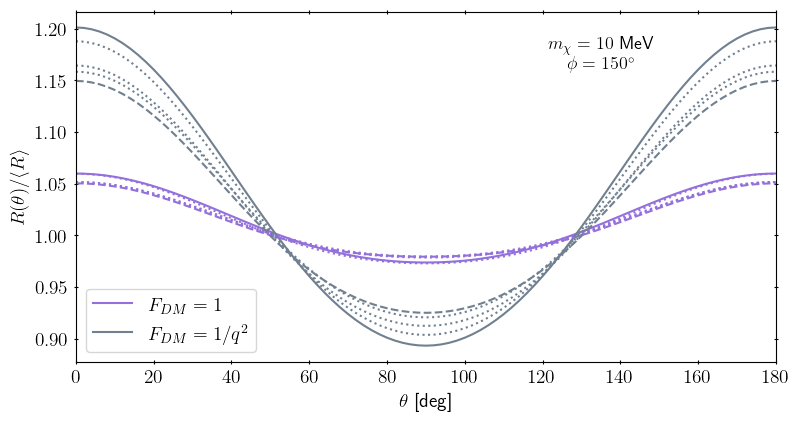

In [28]:
unisize = 3.5
fig = plt.figure(figsize=[2.0*unisize,1*unisize])
ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')

mX = 10
phi = 150

ax.plot(thetas, rate_rm_phi[('tot', 0, mX, phi)], color='mediumpurple', label=r'$F_{DM}=1$')
ax.plot(thetas, rate_rm_phi[('tot', 2, mX, phi)], color='slategray', label=r'$F_{DM}=1/q^2$')

ax.plot(thetas, rate_rm_phi[('s1', 0, mX, phi)], color='mediumpurple', linestyle='dashed')
ax.plot(thetas, rate_rm_phi[('s1', 2, mX, phi)], color='slategray', linestyle='dashed')

ax.plot(thetas, rate_rm_phi[('s1s2', 0, mX, phi)], color='mediumpurple', linestyle='dotted')
ax.plot(thetas, rate_rm_phi[('s1s2', 2, mX, phi)], color='slategray', linestyle='dotted')

ax.plot(thetas, rate_rm_phi[('s1s5', 0, mX, phi)], color='mediumpurple', linestyle='dotted')
ax.plot(thetas, rate_rm_phi[('s1s5', 2, mX, phi)], color='slategray', linestyle='dotted')

ax.plot(thetas, rate_rm_phi[('s1s8', 0, mX, phi)], color='mediumpurple', linestyle='dotted')
ax.plot(thetas, rate_rm_phi[('s1s8', 2, mX, phi)], color='slategray', linestyle='dotted')

ax.set_xlim([0,  180])
# ax.set_ylim([1e-10, 2])
# ax.set_xticks([j for j in range(0, ellMax+1, 2)])
ax.set_ylabel(r'$R(\theta)/\langle R \rangle$', fontsize=14, usetex=True)
ax.set_xlabel(r'$\theta$ [deg]', fontsize=14, usetex=True)
ax.tick_params(axis='both', labelsize=14, direction='inout',
               right=True, top=True, labelleft=True, labelright=False,
               labelbottom=True, labeltop=False)

ax.text(0.75, 0.93, r'$m_\chi = {}$ MeV'.format(mX)+'\n' + '$\phi = {}^\circ$'.format(phi), 
        horizontalalignment='center',
        verticalalignment='top', fontsize=13, 
        color='black', backgroundcolor='white',
        transform=ax.transAxes, usetex=True)


ax.legend(fontsize=14)

# plt.savefig('out/TSdiff_R_n_0.pdf', format="pdf", bbox_inches='tight')

fig.show()

## Conical Slices (Fixed $\theta$)

In [ ]:
rate_rm_theta = {} 
for key in rate_all.keys():
    for theta in thetas:
        label = (key[0], key[1], key[2], theta)
        r_phi = []
        for phi in phis:
            ix = ix_thetaphi(theta, phi)
            r_phi += [rate_all[key][ix]]
        r_phi = np.array(r_phi)
        rate_rm_theta[label] = np.array(r_phi)/rate_angavg[key]

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_83095/3200619544.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


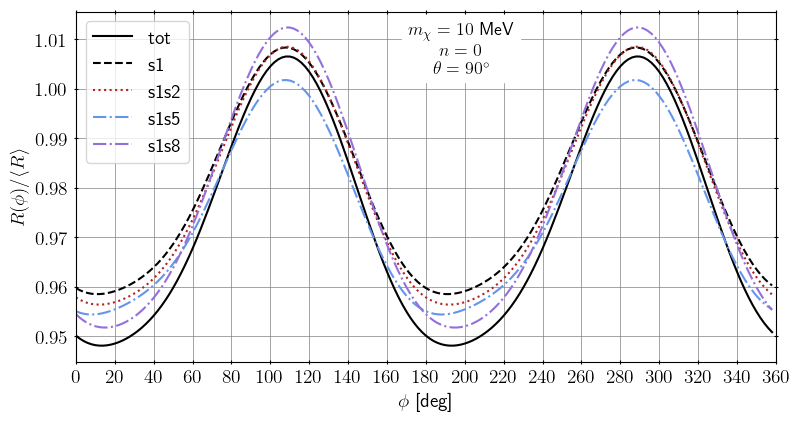

In [19]:
unisize = 3.5
fig = plt.figure(figsize=[2.0*unisize,1*unisize])
ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')

mX = 10
n = 0
theta = 90

sIstyle = {}
sIstyle['tot'] = 'solid'
sIstyle['s1'] = 'dashed'
sIstyle['s1s2'] = 'dotted'
sIstyle['s1s5'] = 'dashdot'
sIstyle['s1s8'] = 'dashdot'

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'black'
sIcolor['s1s2'] = 'firebrick'
sIcolor['s1s5'] = 'cornflowerblue'
sIcolor['s1s8'] = 'mediumpurple'

for sI in ['tot', 's1', 's1s2', 's1s5', 's1s8']:
    ax.plot(phis, rate_rm_theta[(sI, mX, n, theta)], 
            color=sIcolor[sI], label=sI, linestyle=sIstyle[sI])

ax.set_xlim([0,  360])
# ax.set_ylim([1e-10, 2])
ax.set_xticks([ph for ph in range(0, 361, 20)])
ax.grid(color='gray', linestyle='-', linewidth=0.5)
ax.set_ylabel(r'$R(\phi)/\langle R \rangle$', fontsize=14, usetex=True)
ax.set_xlabel(r'$\phi$ [deg]', fontsize=14, usetex=True)
ax.tick_params(axis='both', labelsize=14, direction='inout',
               right=True, top=True, labelleft=True, labelright=False,
               labelbottom=True, labeltop=False)

# leg_x = 0.91
leg_x = 0.55
ax.text(leg_x, 0.97, r'$m_\chi = {}$ MeV'.format(mX)
        +'\n' + r'$n = {}$'.format(n)
        +'\n' + r'$\theta = {}^\circ$'.format(theta), 
        horizontalalignment='center',
        verticalalignment='top', fontsize=13, 
        color='black', 
        backgroundcolor='white',
        transform=ax.transAxes, usetex=True)


ax.legend(fontsize=14)

# plt.savefig('out/R_n{}_mX{}_theta{}.pdf'.format(n, mX, theta), format="pdf", bbox_inches='tight')

fig.show()

This plot of $R(\theta, \phi)$ at $\theta = 90^\circ$ is useful for optimizing the rate. The maximum occurs at $\theta = 0$, and a cone with opening angle $\theta_N \approx 45^\circ$ can intersect this maximum while also passing near the local minimum at $\theta = 90^\circ$. For the $m_\chi = 10$ MeV, $F_{DM} = 1$ model, this occurs at $\phi_{\rm min} \approx 190^\circ$, implying that a crystal orientation of $\beta = \phi_{\rm min} - 90^\circ \approx 100^\circ$ will maximize the modulation amplitude. 

For the $F_{DM} = 1$ form factor, the point $(\theta, \phi) = (90^\circ, 110^\circ)$ is actually a saddle point, as the following 2d plots will show. 

## Pictures of the Complete Sphere

These plots show the full set of possible $R(\theta, \phi)$ for a given DM model. A fixed orientation in the lab would generate daily modulation, with $\theta,\phi$ following a circular cycle on the sphere, in a cone with opening angle $\theta_N$ (the angle between the north pole and the Earth velocity vector). Over the year, $\theta_N$ varies between $36^\circ \leq \theta_N \leq 48.5^\circ$, with the maximum occuring in mid-April, and the minimum around November 1. This is related to, but out of phase with, the modulation in $|\vec v_E|$. 

In [20]:

#opening angles: options a,b,c
thetaN = {}
thetaN['a'] = (90-54)*np.pi/180
thetaN['b'] = (90-48)*np.pi/180
thetaN['c'] = (90-41.5)*np.pi/180

#N pole alignment: options A,B
north_th = {}
north_th['A'] = 42*np.pi/180
north_th['B'] = 90*np.pi/180

#values of beta: 
beta_i = {}
beta_i['1'] = 20*np.pi/180 
beta_i['2'] = 100*np.pi/180 

times = {}
# Rlist = {}
R_coneWG = {}
coneTH = {}
for nth_i,n_theta in north_th.items():
    for bet_j,beta in beta_i.items():
        for th_k,thN in thetaN.items():
            lbl = (nth_i,bet_j,th_k)
            north = (n_theta, np.pi/2 + beta)
            ti,Ri = dailyMod(north, thN, plotpoints=120, t0_h=0.)
            times[lbl] = ti
            # Rlist[lbl] = Ri
            coneTH[lbl] = makeCone(north, thN, plotpoints=120)
            R_coneWG[lbl] = vsdm.WignerG(ellMax, rotations=Ri, lmod=2)
            
#

In [21]:
mu_mod = {}
rate_mod = {}
# rate_angavg = {}
for key in rates.keys():
    rate_mod_cone = {}
    for lbl,wG in R_coneWG.items():
        mod_unnorm = rates[key].mu_R(wG) 
        # R_bar = rate_angavg[key] # normalize by isotropic average <R>
        R_bar = mod_unnorm.mean() # normalize by average for this cycle
        rate_mod_cone[lbl] = mod_unnorm/R_bar
    rate_mod[key] = rate_mod_cone


In [22]:
### ADD THE CONE ###
cone_phi_theta = {} # values of (theta, phi) in degrees for plot
for lbl in coneTH.keys():
    (L, n, l) = lbl
    cone_th = thetaN[l]
    nor_th = north_th[L]
    
    cone_th_ph = coneTH[lbl] * 180/np.pi
    # sort by value of azimuthal angle:
    cone_ph_th = np.flip(cone_th_ph, axis=1)
    if nor_th<cone_th: # this cone goes around the north pole
        d_ph_th = {cone_ph_th[i,0]:cone_ph_th[i,1] for i in range(len(cone_ph_th))}
        keys = np.sort([ph for ph in d_ph_th.keys()])
        sortedcone = [[ph,d_ph_th[ph]] for ph in keys]
        leftpad = [sortedcone[-1][0]-360, sortedcone[-1][1]]
        rightpad = [sortedcone[0][0]+360, sortedcone[0][1]]
        paddedcone = np.array([leftpad] + sortedcone + [rightpad])
        cone_phi_theta[lbl] = np.array(paddedcone)
    else:
        cone_phi_theta[lbl] = cone_ph_th


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_83095/1733700374.py:90: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_83095/1733700374.py:96: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


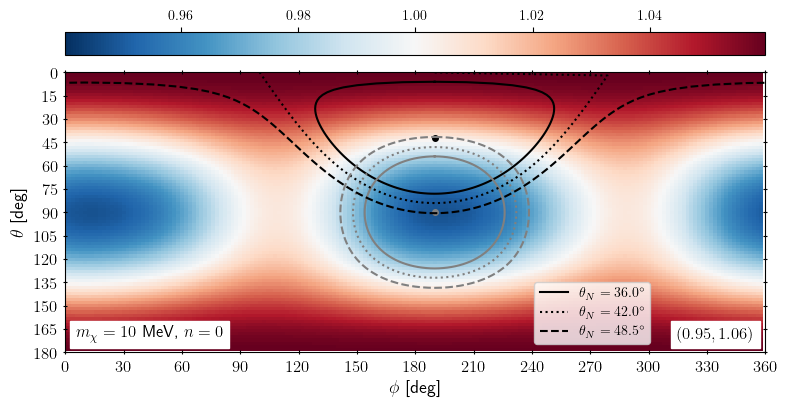

In [23]:
mX = 10
n = 0
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, mX, n)])
max_R = np.max(rate_norm[(sI_2d, mX, n)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


cstyle = {}
cstyle['a'] = 'solid' # 'a': for ~Nov 
cstyle['b'] = 'dotted' # 'b': average thetaN = 42 deg
cstyle['c'] = 'dashed' # 'c': for ~May
clabel = {}
clabel['a'] = r'$\theta_N={:.1f}^\circ$'.format(90-54)
clabel['b'] = r'$\theta_N={:.1f}^\circ$'.format(42)
clabel['c'] = r'$\theta_N={:.1f}^\circ$'.format(90-41.5)
ncolor = {'A': 'black', 'B': 'gray'} # color coded for north_theta value: 42, 90 degrees


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, mX, n)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)
### markers for location of north pole:
for bl in ['2']:
    for nl in ['A', 'B']:
        ax1.plot([90 + 180/np.pi*beta_i[bl]], [180/np.pi*north_th[nl]], color=ncolor[nl], 
                 marker='o', markersize=4)
### draw the cones:
for bl in ['2']:
    for cl in ['a', 'b', 'c']:
        # draw one set of beta with line labels:
        for nl in ['A']:
            lbl = (nl,bl,cl)
            ax1.plot(cone_phi_theta[lbl][:,0], cone_phi_theta[lbl][:,1], 
                     color=ncolor[nl], linestyle=cstyle[cl],
                     label=clabel[cl])
        # draw one set of beta without line labels:
        for nl in ['B']:
            lbl = (nl,bl,cl)
            ax1.plot(cone_phi_theta[lbl][:,0], cone_phi_theta[lbl][:,1], 
                     color=ncolor[nl], linestyle=cstyle[cl])
            

# ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$, $\beta={}^\circ$'.format(mX, n, beta), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'$({:.2f}, {:.2f})$'.format(min_R, max_R), horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)


# ax1.legend(loc='lower center')
ax1.legend(loc=(0.67, 0.03))


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)

# plt.savefig('out/cone/cone_eg_mX{}_n{}.png'.format(mX, n), format="png", dpi=300, bbox_inches='tight')

fig.show()

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_83095/1252742295.py:95: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_83095/1252742295.py:157: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


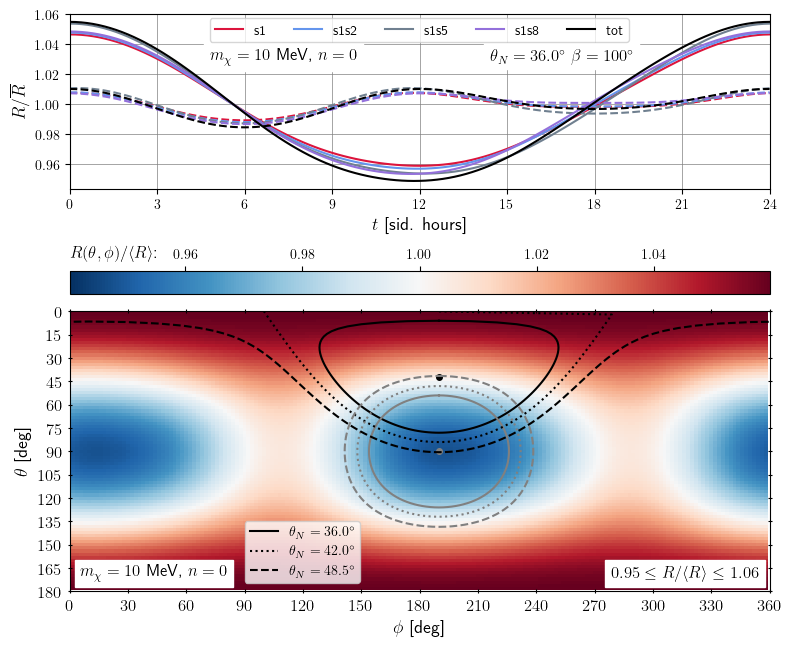

In [24]:
mX = 10
n = 0
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

betas = ['2']

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, mX, n)])
max_R = np.max(rate_norm[(sI_2d, mX, n)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


cstyle = {}
cstyle['a'] = 'solid' # 'a': for ~Nov 
cstyle['b'] = 'dotted' # 'b': average thetaN = 42 deg
cstyle['c'] = 'dashed' # 'c': for ~May
clabel = {}
clabel['a'] = r'$\theta_N={:.1f}^\circ$'.format(90-54)
clabel['b'] = r'$\theta_N={:.1f}^\circ$'.format(42)
clabel['c'] = r'$\theta_N={:.1f}^\circ$'.format(90-41.5)
ncolor = {'A': 'black', 'B': 'gray'} # color coded for north_theta value: 42, 90 degrees


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, mX, n)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)
### markers for location of north pole:
for bl in betas:
    for nl in ['A', 'B']:
        ax1.plot([90 + 180/np.pi*beta_i[bl]], [180/np.pi*north_th[nl]], color=ncolor[nl], 
                 marker='o', markersize=4)
### draw the cones:
for bl in betas:
    for cl in ['a', 'b', 'c']:
        # draw one set of beta with line labels:
        for nl in ['A']:
            lbl = (nl,bl,cl)
            ax1.plot(cone_phi_theta[lbl][:,0], cone_phi_theta[lbl][:,1], 
                     color=ncolor[nl], linestyle=cstyle[cl],
                     label=clabel[cl])
        # draw one set of beta without line labels:
        for nl in ['B']:
            lbl = (nl,bl,cl)
            ax1.plot(cone_phi_theta[lbl][:,0], cone_phi_theta[lbl][:,1], 
                     color=ncolor[nl], linestyle=cstyle[cl])
            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.0, 1.18, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)

ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\overline{R}$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
sIcolor['s1s2'] = 'cornflowerblue'
sIcolor['s1s5'] = 'slategray'
sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}


for bet_j in betas:
    beta = beta_i[bet_j]
    for th_k in ['a']:
        thN = thetaN[th_k]
        for sI in ['s1', 's1s2', 's1s5', 's1s8', 'tot']:
            for nth_i in ['A']:
                n_theta = north_th[nth_i]
                lbl = (nth_i,bet_j,th_k)
                tH = times[lbl]
                rate = rate_mod[(sI, mX, n)][lbl]
                ax2.plot(tH, rate, color=sIcolor[sI], label=sI, linestyle=nstyle[nth_i])
            for nth_i in ['B']:
                n_theta = north_th[nth_i]
                lbl = (nth_i,bet_j,th_k)
                tH = times[lbl]
                rate = rate_mod[(sI, mX, n)][lbl]
                ax2.plot(tH, rate, color=sIcolor[sI], linestyle=nstyle[nth_i])

ax2.text(0.2, 0.8, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)
betalabel = int(round(beta*180/np.pi))
ax2.text(0.6, 0.8, r'$\theta_N={:.1f}^\circ$'.format(thN*180/np.pi)
         +' '+r'$\beta={}^\circ$'.format(betalabel), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

ax2.legend(ncol=5, loc=(0.2,0.84))

# plt.savefig('out/modRate_mX{}_n{}_b{}.png'.format(mX, n, betalabel), 
#             format="png", dpi=300, bbox_inches='tight')

fig.show()

## Rate in events per second:

The total rate depends on the detector mass, exposure time, DM cross section, and local DM density. The "rate" calculated so far is a dimensionless quantity $\mu$, independent of these factors, and scaled by some powers of $v_0 \equiv {\rm VMAX}$ and $q_0 \equiv {\rm QMAX}$. To get the number of expected events, we multiply the dimensionless rate $\mu$ by a basis-dependent dimensionless exposure factor $k_0$, 
$$k_0 = N_T \rho_\chi \bar\sigma_0 \frac{v_0^2}{q_0},$$
so that the expected event rate is:
$$R = \frac{k_0}{T_{exp}} \sum_{\ell, m, m'} K^{(\ell)}_{m m'} G^{(\ell)}_{m m'}.$$

In [25]:
"""exposure factor for 1 kg of trans-stilbene, for 1 second"""
k0 = vsdm.g_k0(exp_kgyr=1./(3.15e7), mCell_g=721.0, 
               sigma0_cm2=1e-34, rhoX_GeVcm3=0.4, 
               v0=Vbasis['u0'], q0=Qbasis['u0'])

"""angular averages <R> for each model:"""
print('rates in Hz:')
for sI_m_n in rates.keys():
    K000 = rates[sI_m_n].vecK[0]
    print('{}: {}'.format(sI_m_n, K000*k0))

rates in Hz:
('s1', 10, 0): 0.6920830630751752
('s1', 10, 2): 0.17602764241302818
('s2', 10, 0): 0.07474009504391786
('s2', 10, 2): 0.02885184051373925
('s5', 10, 0): 0.0931982491902819
('s5', 10, 2): 0.01795280939392286
('s8', 10, 0): 0.11517971407079024
('s8', 10, 2): 0.018859245871115725
('s1s2', 10, 0): 0.766823158119093
('s1s5', 10, 0): 0.7852813122654572
('s1s8', 10, 0): 0.8072627771459655
('tot', 10, 0): 0.9752011213801651
('s1s2', 10, 2): 0.20487948292676741
('s1s5', 10, 2): 0.19398045180695103
('s1s8', 10, 2): 0.19488688828414388
('tot', 10, 2): 0.241691538191806


# Daily Modulation for arbitrary cube orientation

In [248]:
"""
In the (x,y,z) crystal coordinate system, a normal vector 

    u = (theta_u, phi_u) 
    
points up. The initial orientation (beta=0) of the crystal 
points the z axis towards the northern horizon.

latitude: angle between north pole axis and the horizon
theta_u: angle between z axis and the u vector 
phi_u: azimuthal coordinate of u vector in (x,y,z) basis
theta_Nu: angle between u vector and north pole 

    theta_Nu = 90 degrees - latitude 
    
theta_N: angle between north pole and the z axis of the crystal, 
    at beta = 0: 
    
    theta_N = |theta_Nu - theta_u|

phi_N: azimuthal coordinate of the north pole (beta=0)

    if theta_Nu > theta_u: then phi_N = phi_u + 180 degrees
    if theta_Nu < theta_u: then phi_N = phi_u
    
location of north pole (beta=0): 
    N_0 = (theta_N, phi_N)
    
the operator R_beta rotates the crystal by an angle beta about the u axis
this moves the north pole location to: 

    N_beta = inverse(R_beta) * N_0
"""
deg = np.pi/180 

def get_N0(u_sph, latitude):
    deg = np.pi/180 
    theta_Nu = 90*deg - latitude 
    u_theta, u_phi = u_sph 
    theta_N = np.abs(u_theta - theta_Nu)
    if theta_Nu > u_theta:
        phi_N = ((u_phi/deg + 180)%360 )*deg
    else:
        phi_N = u_phi
    return (theta_N, phi_N)

def dailyModInterp(data_intp, north, thetaN, plotpoints=100, t0_h=0.):
    # data_intp: an interpolated 2d grid object, with theta and phi in degrees!
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    t_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    t = t0_h #initial time, in sidereal hours
    for theta,phi in theta_phi_list:        
        R = data_intp([theta/deg, phi/deg])[0]
        R_list += [R]
        t_list += [t]
        t += dt_h
    return np.array(t_list),R_list

def RMSmod(data_intp, north, thetaN, plotpoints=120):
    # data_intp: an interpolated 2d grid object, with theta and phi in degrees!
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    for theta,phi in theta_phi_list[:-1]:        
        R = data_intp([theta/deg, phi/deg])[0]
        R_list += [R]
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq

def fRMSmod(data_intp, north, thetaN, plotpoints=120):
    # data_intp: an interpolated 2d grid object, with theta and phi in degrees!
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    for theta,phi in theta_phi_list[:-1]:        
        R = data_intp([theta/deg, phi/deg])[0]
        R_list += [R]
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq / Rbar

def chi2norm(data_intp, north, thetaN, plotpoints=120):
    # data_intp: an interpolated 2d grid object, with theta and phi in degrees!
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    for theta,phi in theta_phi_list[:-1]:        
        R = data_intp([theta/deg, phi/deg])[0]
        R_list += [R]
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq**2 / Rbar



In [33]:
"""
For rotations: evaluating R(theta,phi) using wG above.
Rather than creating a new WignerG for the daily modulation curves, 
interpolate from the saved 2d grid of R(theta, phi).
"""
# points = np.array([[(thetas, phis)  for phi in phis] for theta in thetas])
# print(np.shape(points))
rn_intp = {}
for key in rate_norm.keys():
#     data = np.array([[(thetas[ix], phis[iy], rate_norm[key][ix, iy]) 
#                       for iy in range(len(phis))] 
#                      for ix in range(len(thetas))])
    data = np.array([[rate_norm[key][ix, iy]
                      for iy in range(len(phis))] 
                     for ix in range(len(thetas))])
#     rn_intp[key] = interp.interpn(points, rate_norm[key], points)
#     rn_intp[key] = interp.interpn((thetas, phis), rate_norm[key], points)
    rn_intp[key] = interp.RegularGridInterpolator((thetas, phis), data)

In [63]:
# Check accuracy of interpolation
model_ix = 10
ix,iy = (54, 173)
theta, phi = thetas[ix], phis[iy]

data_intp = rn_intp[modellist[model_ix]]

print(theta, phi)
print(rate_norm[modellist[model_ix]][ix,iy], '\t', data_intp([theta, phi])[0])


# for example:
latitude = 41.7*deg 
theta_Nu = 90*deg - latitude 

# normal vector u that points 'up' in the lab:
u_theta = 25*deg 
u_phi = 137*deg 
up = (u_theta, u_phi)

# direction of 'north' in crystal basis:
north = get_N0(up, latitude)
print('north (rad):', north)
# cone of opening angle thetaN centered at 'north':
thetaN = 40.0*deg 
cone = makeCone(north, thetaN, plotpoints=22)
print(cone[:,0]/deg )
print(cone[:,1]/deg )
tH, R_t = dailyModInterp(data_intp, north, thetaN, plotpoints=100)
print(np.mean(R_t[:-1]))

108 346
0.9191366034376973 	 0.9191366034376973
north (rad): (0.40666171571467874, 5.532693728822025)
[16.7        18.64394172 23.44233506 29.53319794 35.98306028 42.28948939
 48.13429269 53.27672827 57.51551148 60.68041177 62.63754074 63.3
 62.63754074 60.68041177 57.51551148 53.27672827 48.13429269 42.28948939
 35.98306028 29.53319794 23.44233506 18.64394172 16.7       ]
[137.         102.49521454  76.12723332  56.76473965  41.35844244
  28.0071743   15.68814908   3.84260916 352.16215036 340.48904723
 328.76558796 317.         305.23441204 293.51095277 281.83784964
 270.15739084 258.31185092 245.9928257  232.64155756 217.23526035
 197.87276668 171.50478546 137.        ]
1.0520122672542045


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_20583/312203734.py:30: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


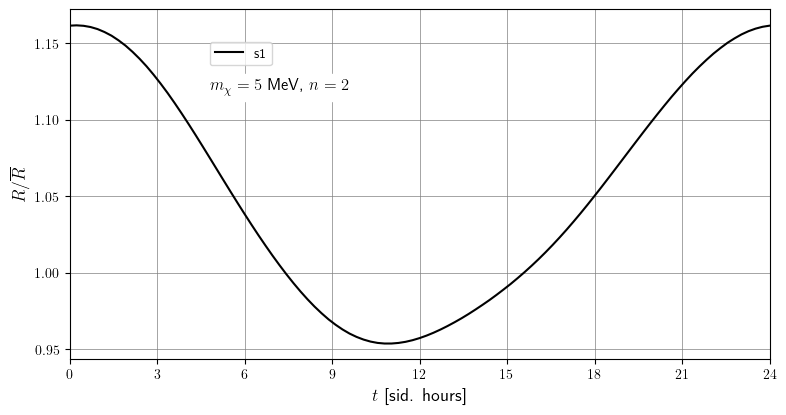

In [54]:
# mX = 10
# n = 0
# sI = 's1'
(sI, n, mX) = modellist[model_ix]

fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')

ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\overline{R}$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

ax2.plot(tH, R_t, color='black', label=sI)

ax2.text(0.2, 0.8, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

ax2.legend(loc=(0.2,0.84))

# plt.savefig('out/modRate_mX{}_n{}_b{}.png'.format(mX, n, betalabel), 
#             format="png", dpi=300, bbox_inches='tight')

fig.show()

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_20583/155183083.py:53: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_20583/155183083.py:58: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


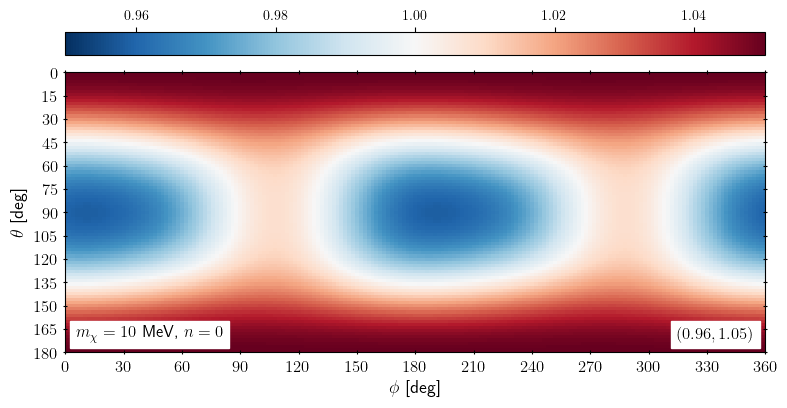

In [55]:
mX = 10
n = 0
sI_2d = 's1' # index to use for 2d rate plot R(theta, phi)

unisize = 3.5

min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'$({:.2f}, {:.2f})$'.format(min_R, max_R), horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)


# ax1.legend(loc='lower center')
# ax1.legend(loc=(0.67, 0.03))


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)


fig.show()

# Daily Modulation Plots using Interpolation

In [233]:

cones = {}
norths = {}
thNs = {}
ups = {}
# Example 1: a detector in Fermilab...
latitude = 41.7*deg 
theta_Nu = 90*deg - latitude 

conelbl = 'Jan_a'
# ...operating in early January...
thetaN = 40*deg 
# thetaN = 47*deg 
thNs[conelbl] = thetaN

# ...normal vector u that points 'up' in the lab:
u_theta = 25*deg 
u_phi = 137*deg 
up = (u_theta, u_phi)
ups[conelbl] = up
# direction of 'north' in crystal basis:
north = get_N0(up, latitude)
# norths[conelbl] = [north[0]/deg, north[1]/deg]
norths[conelbl] = north

conelbl = 'Jan_b'
# ...operating in early January...
thetaN = 40*deg 
# thetaN = 47*deg 
thNs[conelbl] = thetaN

# ...normal vector u that points 'up' in the lab:
u_theta = 90*deg 
u_phi = 0*deg 
up = (u_theta, u_phi)
ups[conelbl] = up
# direction of 'north' in crystal basis:
north = get_N0(up, latitude)
# norths[conelbl] = [north[0]/deg, north[1]/deg]
norths[conelbl] = north

conelbl = 'Jan_c'
# ...operating in early January...
thetaN = 40*deg 
# thetaN = 47*deg 
thNs[conelbl] = thetaN

# ...normal vector u that points 'up' in the lab:
u_theta = 0*deg 
u_phi = (195+180)*deg 
up = (u_theta, u_phi)
ups[conelbl] = up
# direction of 'north' in crystal basis:
north = get_N0(up, latitude)
# norths[conelbl] = [north[0]/deg, north[1]/deg]
norths[conelbl] = north

for lbl in norths.keys():
    north = norths[lbl]
    thetaN = thNs[lbl]
    # cone of opening angle thetaN centered at 'north':
    this_cone = makeCone(north, thetaN, plotpoints=120)
    # cones[conelbl] = this_cone/deg # convert to degrees for 2d plot
    cones[lbl] = this_cone # don't convert to degrees for 2d plot

### shift the cone to start at discontinuity ###
cone_phi_thetas = {} # values of (phi, theta) in degrees for plot
for lbl in cones.keys():
    cone = cones[lbl]/deg 
    shift_ix = 0
    for ix in range(1, len(cone)):
        prev = cone[ix-1]
        this = cone[ix]
        diff = np.abs(this - prev)
        if diff[0] > 50 or diff[1] > 50:
            shift_ix = ix
            break
    cone = np.roll(cone, -shift_ix, axis=0)
    cone = np.roll(cone, 1, axis=1) # switch to (phi, theta) for 2d plots
    cone_phi_thetas[lbl] = cone


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_20583/3833765137.py:124: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_20583/3833765137.py:182: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


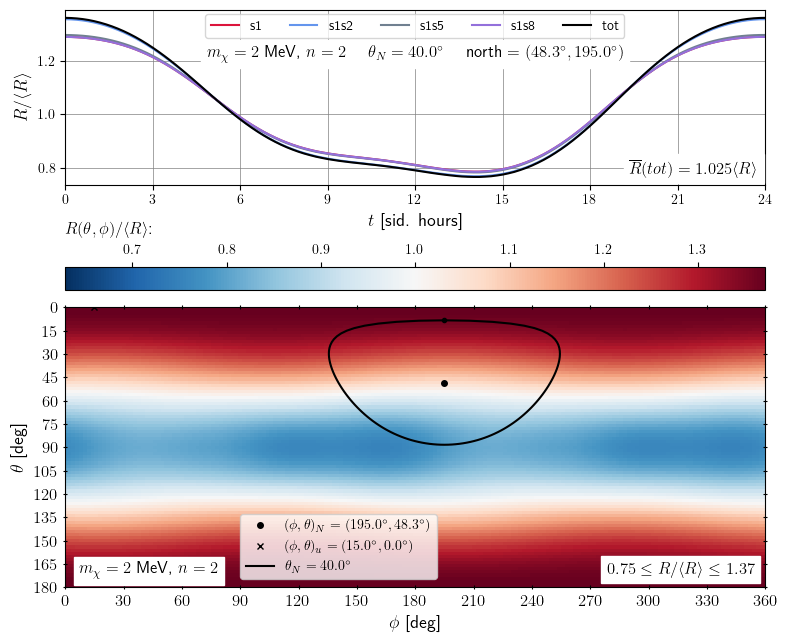

In [261]:
mX = 2
n = 2
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

"""Cones for daily modulation plot:"""

conelbl = 'Jan_c'

lbls = [conelbl]

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)

        
# make daily modulation plots: one for every (cone, sI) combination
tHs = {}
Rts = {}
R_bar = {}
for lbl in lbls:
    north = norths[lbl]
    thetaN = thNs[lbl]
    for sI in ['s1', 's1s2', 's1s5', 's1s8', 'tot']:
        data_intp = rn_intp[(sI, n, mX)]
        tH, Rt = dailyModInterp(data_intp, north, thetaN, plotpoints=120)
        tHs[(lbl, sI)] = tH
        Rts[(lbl, sI)] = Rt
        barR = np.mean(Rt[:-1])
        R_bar[(lbl, sI)] = barR # average R, in units of <R>, for this cycle
        
cstyle = {}
cstyle[conelbl] = 'solid' # 'a': for ~Nov 
# cstyle['b'] = 'dotted' # 'b': average thetaN = 42 deg
# cstyle['c'] = 'dashed' # 'c': for ~May
clabel = {}
clabel[conelbl] = r'$\theta_N={:.1f}^\circ$'.format(thetaN/deg)
# clabel['b'] = r'$\theta_N={:.1f}^\circ$'.format(42)
# clabel['c'] = r'$\theta_N={:.1f}^\circ$'.format(90-41.5)
ncolor = {conelbl: 'black'} # color coded for north_theta value: 42, 90 degrees



"""Panel 1: Rate as function of (theta, phi)"""

xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)
### markers for locations of north pole, 'up', and 't=0':
for lbl in lbls:
    # north:
    north = norths[lbl]
    n_phi = north[1]/deg
    n_theta = north[0]/deg
    # print(np.array(north)/deg)
    ax1.plot([n_phi], [n_theta], 
             label=r'$(\phi,\theta)_N=({:.1f}^\circ,{:.1f}^\circ)$'.format(n_phi, n_theta),
             color=ncolor[lbl], 
             linestyle='None',
             marker='o', markersize=4)
    # up:
    up = ups[lbl]
    u_phi_deg = (up[1]/deg)%360
    u_theta_deg = up[0]/deg
    ax1.plot([u_phi_deg], [u_theta_deg], 
             label=r'$(\phi,\theta)_u=({:.1f}^\circ,{:.1f}^\circ)$'.format(u_phi_deg, u_theta_deg),
             color=ncolor[lbl], 
             linestyle='None',
             marker='x', markersize=4)
    cone_phi_theta = cone_phi_thetas[lbl]
    ax1.plot(cone_phi_theta[:,0], cone_phi_theta[:,1], 
             color=ncolor[lbl], linestyle=cstyle[lbl],
             label=clabel[lbl])
    # t=0:
    th0,ph0 = cones[lbl][0]
    ax1.plot([ph0/deg], [th0/deg], 
             color=ncolor[lbl], 
             linestyle='None',
             marker='o', markersize=3)

            
ax1.text(0.02, 0.03, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)


"""Panel 2: Daily Modulation"""


ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
sIcolor['s1s2'] = 'cornflowerblue'
sIcolor['s1s5'] = 'slategray'
sIcolor['s1s8'] = 'mediumpurple'


for lbl in lbls:
    # north = norths[lbl]
    # thetaN = thNs[lbl]
    for sI in ['s1', 's1s2', 's1s5', 's1s8', 'tot']:
        tH = tHs[(lbl, sI)]
        Rt = Rts[(lbl, sI)]
        ax2.plot(tH, Rt, color=sIcolor[sI], label=sI, linestyle=cstyle[lbl])

ax2.text(0.5, 0.7, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n)+r' \quad '
         +r'$\theta_N={:.1f}^\circ$'.format(thNs[conelbl]/deg)+r' \quad '
         +r'north = $({:.1f}^\circ,{:.1f}^\circ)$'.format(norths[conelbl][0]/deg, 
                                                          norths[conelbl][1]/deg),
         horizontalalignment='center',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

barR = R_bar[(conelbl, 'tot')]
ax2.text(0.99, 0.04, r'$\overline R(tot)={:.3f}\langle R \rangle$'.format(barR),
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

ax2.legend(ncol=5, loc=(0.2,0.84))
    
# plt.savefig('out/ratemod_{}_n{}_mX{}.png'.format(conelbl, n, mX), 
#             format="png", dpi=300, bbox_inches='tight')

fig.show()

### Save modulation plots to HDF5:

In [239]:
hdf5file = 'out/modrates.hdf5'
with h5py.File(hdf5file,'w') as hdf5: #create file if it does not exist
    for lbl in ['Jan_a', 'Jan_b', 'Jan_c']:
        north = norths[lbl]
        thetaN = thNs[lbl]
        # save these values for HDF5 attrs dict:
        vals = {}
        vals["label"] = lbl
        vals["lat [deg]"] = latitude/deg
        vals["thetaN [deg]"] = thetaN/deg
        (u_theta, u_phi) = ups[lbl]
        vals["up_theta [deg]"] = u_theta/deg
        vals["up_phi [deg]"] = (u_phi/deg)%360
        for n in [0, 2]:
            for mX in [2, 5, 10, 50]:
                modelDM = {}
                modelDM['fdm_n'] = n
                modelDM['mX [MeV]'] = mX
                gname = '{}/{}/{}'.format(lbl, n, mX)
                group = hdf5.create_group(gname)
                group.attrs.update(vals)
                group.attrs.update(modelDM)
                data_s1 = rn_intp[('s1', n, mX)]
                tH, Rt_s1 = dailyModInterp(data_s1, north, thetaN, plotpoints=120)
                data_tot = rn_intp[('tot', n, mX)]
                tH, Rt_tot = dailyModInterp(data_tot, north, thetaN, plotpoints=120)
                dset_t = group.create_dataset('tH', data=tH)
                dset_R1 = group.create_dataset('R_s1', data=Rt_s1)
                dset_R1.attrs['state'] = 's1'
                dset_R1.attrs['<R>'] = rate_angavg[('s1', n, mX)]
                dset_R1.attrs.update(modelDM)
                dset_tot = group.create_dataset('R_tot', data=Rt)
                dset_tot.attrs['state'] = 'tot'
                dset_tot.attrs['<R>'] = rate_angavg[('tot', n, mX)]
                dset_tot.attrs.update(modelDM)


In [245]:
with h5py.File(hdf5file,'r') as hdf5:  
    gname = '{}/{}/{}'.format('Jan_a', 2, 50)
    group = hdf5[gname]
    print(group.keys())
    dname = 'tH'
    tH = np.array([row for row in group[dname]])
    print(tH)
    attrs = {}
    attrs.update(group.attrs)
    print(attrs)
    # print(attrs['up_theta [deg]'])
    # print(attrs['up_phi [deg]'])

<KeysViewHDF5 ['R_s1', 'R_tot', 'tH']>
[ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10.  10.2 10.4 10.6 10.8 11.
 11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6 12.8 13.  13.2 13.4 13.6 13.8
 14.  14.2 14.4 14.6 14.8 15.  15.2 15.4 15.6 15.8 16.  16.2 16.4 16.6
 16.8 17.  17.2 17.4 17.6 17.8 18.  18.2 18.4 18.6 18.8 19.  19.2 19.4
 19.6 19.8 20.  20.2 20.4 20.6 20.8 21.  21.2 21.4 21.6 21.8 22.  22.2
 22.4 22.6 22.8 23.  23.2 23.4 23.6 23.8 24. ]
{'fdm_n': 2, 'label': 'Jan_a', 'lat [deg]': 41.7, 'mX [MeV]': 50, 'thetaN [deg]': 40.0, 'up_phi [deg]': 137.0, 'up_theta [deg]': 25.0}


In [246]:
with h5py.File(hdf5file,'a') as hdf5: #create file if it does not exist
    print(hdf5.keys())
    print(hdf5['Jan_b/2'].keys())


<KeysViewHDF5 ['Jan_a', 'Jan_b', 'Jan_c']>
<KeysViewHDF5 ['10', '2', '5', '50']>


### RMS amplitude and significance score 

In the gaussian limit of many ($\gtrsim 50$) events per day, the expected statistical significance of a modulating signal scales as $N_\sigma \approx \sqrt{ \chi^2}$, with 
$$\chi^2 \simeq (R_0 T) \times f_{\rm RMS}^2,$$ 
$$f_{\rm RMS} = \frac{1}{R_0} \sqrt{\int_0^T \frac{dt}{T} \left( R(t) - R_0 \right)^2}.$$
Here $T$ is the observation time, and $R_0$ is the average number of events (i.e. $R_0 T$ is the total number of events). The rate $R(t)$ is either the measured distribution of events as a function of time, or it is the predicted rate of events: including a DM signal $R_{\rm DM}$ and a constant background $R_{\rm background}$, for example,
$$ R(t) = R_{\rm DM}(t) + R_{\rm background}.$$ 

In [264]:
for lbl in ['Jan_a', 'Jan_b', 'Jan_c']:
    north = norths[lbl]
    thetaN = thNs[lbl]
    print(lbl, '\t(n, mX)\t\tf_RMS:\tsignificance factor:')
    for n in [0, 2]:
        for mX in [2, 5, 10, 50]:
            data_tot = rn_intp[('tot', n, mX)]
            f_rms = fRMSmod(data_tot, north, thetaN, plotpoints=120)
            chi2score = chi2norm(data_tot, north, thetaN, plotpoints=120)
            print('\t ({}, {}):\t {:.2f}%\t {:.3g}'.format(n, mX, f_rms*100, np.sqrt(chi2score)))


Jan_a 	(n, mX)		f_RMS:	significance factor:
	 (0, 2):	 8.88%	 0.0932
	 (0, 5):	 3.73%	 0.0379
	 (0, 10):	 2.21%	 0.0223
	 (0, 50):	 1.69%	 0.017
	 (2, 2):	 13.12%	 0.139
	 (2, 5):	 8.87%	 0.0917
	 (2, 10):	 7.55%	 0.0776
	 (2, 50):	 6.64%	 0.0679
Jan_b 	(n, mX)		f_RMS:	significance factor:
	 (0, 2):	 19.68%	 0.198
	 (0, 5):	 7.25%	 0.0726
	 (0, 10):	 3.82%	 0.0383
	 (0, 50):	 2.75%	 0.0276
	 (2, 2):	 20.57%	 0.211
	 (2, 5):	 12.68%	 0.129
	 (2, 10):	 10.15%	 0.103
	 (2, 50):	 8.36%	 0.0846
Jan_c 	(n, mX)		f_RMS:	significance factor:
	 (0, 2):	 20.98%	 0.209
	 (0, 5):	 7.47%	 0.0744
	 (0, 10):	 3.88%	 0.0388
	 (0, 50):	 2.79%	 0.0279
	 (2, 2):	 21.09%	 0.214
	 (2, 5):	 12.77%	 0.129
	 (2, 10):	 10.11%	 0.102
	 (2, 50):	 8.21%	 0.0826
